In [155]:
import random
from scipy.stats.mstats import gmean

In [156]:
import numpy as np
import pandas as pd
from pycaret.regression import get_config
from pycaret.regression import set_config
from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    tune_model,
    ensemble_model,
    models,
    blend_models,
    stack_models,
    plot_model,
    evaluate_model,
    interpret_model,
    automl,
    predict_model,
    save_model,
    load_model,
    convert_model,
    create_api,
    create_docker
)
from pycaret.utils import version
from yellowbrick.regressor import CooksDistance

In [157]:
id_cols = ['productID',"name","pProductID", "wine_url","pageName","uploadDate"]
target_cols = ['WS']
categorical_cols=[
    "description", "productPrice", "productCompetitiveIntensity", "ProductAvailability", "priceCurrency", 	"additionalType" ,"productOrigin", "productVarietal", "productRegion"
]
extra_cols=["shippingRegion", "shipToState"]
other_ratings = [ 'JS', 'WW', 'D', 'BH', 'W&S', 'WE', 'RP', 'JD', 'SJ', 'V', 'CG', 'TP' ]
predictors = [
    'productStock',
    'price',
    'prodAlcoholPercent_percent'
    #'averageRating_bestRating',
    #'averageRating_worstRating',
    #'bestRating',
    #'worstRating',
    #'prodAlcoholVolume_text',
]

In [158]:
print(f"pycaret version = {version()}")
print("1. Loading Dataset")
df = pd.read_csv("wines_ship_to_pa.csv")
df = df.drop_duplicates('wine_url') 

pycaret version = 3.0.3
1. Loading Dataset


In [159]:
df['prodAlcoholVolume_text'].unique()
[750., 0., 1500., 375., 187., 1000.,  500., 3000.,700., 6000.]

[750.0, 0.0, 1500.0, 375.0, 187.0, 1000.0, 500.0, 3000.0, 700.0, 6000.0]

In [160]:
df = df[df['prodAlcoholVolume_text']==750]

In [161]:
virtual_ws = load_model("best-model")
virtual_ws_other = load_model("predict_ws_from_other/best-model-other")

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


In [163]:
df["ws_pred_1"] = virtual_ws.predict(df[predictors])
df["ws_pred_2"] = virtual_ws_other.predict(df[other_ratings])
df['ws_pred'] = gmean([df["ws_pred_1"],df["ws_pred_2"]])

Text(0, 0.5, 'actual WS rating')

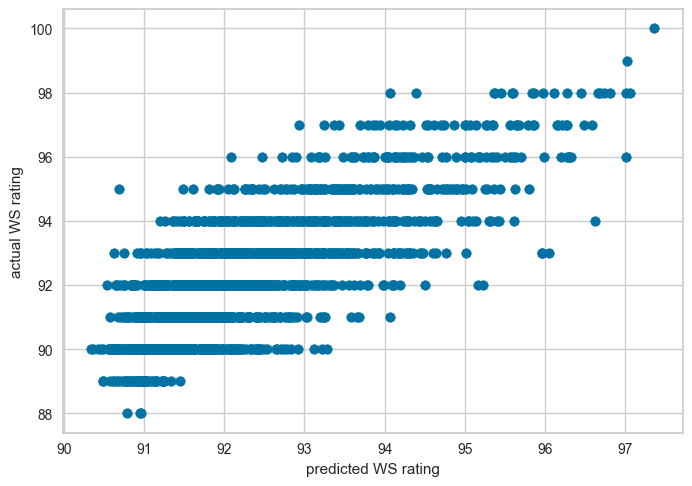

In [164]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(df['ws_pred'],df['WS'])
ax.set_xlabel('predicted WS rating')
ax.set_ylabel('actual WS rating')

In [165]:
def desire(h, low, target, high):
    if h <= low:
        return 0.0
    if h >= high:
        return 0.0
    if low < h <= target:
        return -low / (-low + target) + h / (-low + target)
    if target <= h < high:
        return 1.0 + target / (high - target) - h / (high - target)


In [166]:
from functools import partial

In [167]:
pdesire = partial(desire,low=0, target=5, high=100)

In [168]:
wdesire = partial(desire,low=89,target=100,high=105)

Text(0, 0.5, 'desire')

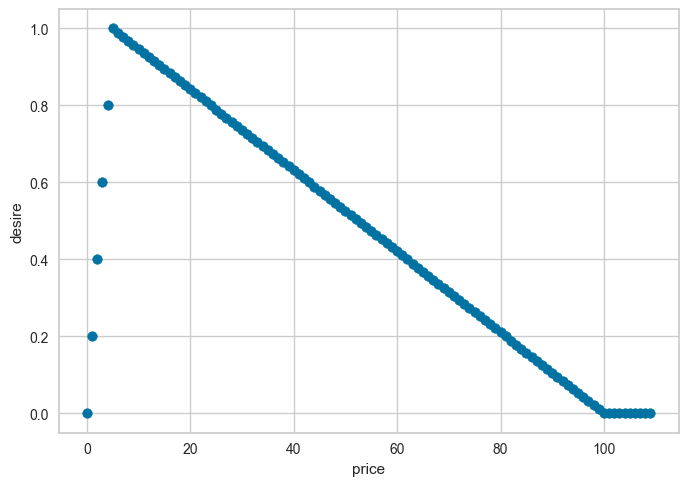

In [169]:
x=pd.Series(np.arange(0,110))
y=x.apply(pdesire)
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(x,y)
ax.set_xlabel('price')
ax.set_ylabel('desire')

Text(0, 0.5, 'desire')

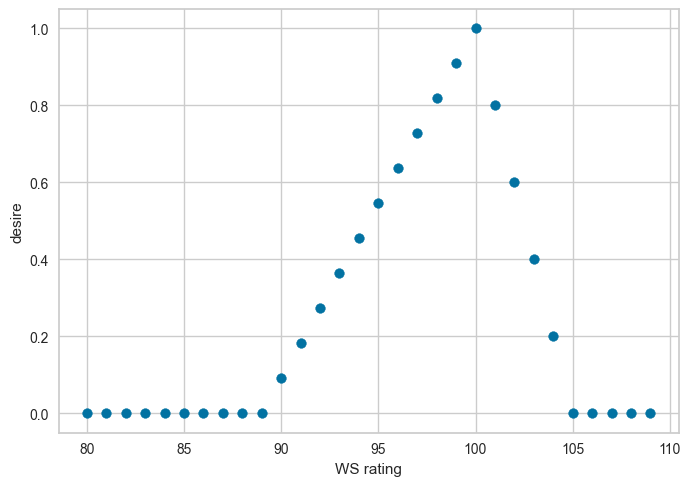

In [170]:
x=pd.Series(np.arange(80,110))
y=x.apply(wdesire)
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(x,y)
ax.set_xlabel('WS rating')
ax.set_ylabel('desire')

In [171]:

def composite(pd,wd):
    return gmean([pd,wd],axis=0)
    

In [172]:
df['price_desire'] = df['price'].apply(pdesire)

In [173]:
df['ws_desire'] = df['WS'].apply(wdesire)

In [174]:
df['ws_pred_desire'] = df['ws_pred'].apply(wdesire)

In [175]:
df['composite_desire_pred'] = composite(df['price_desire'],df['ws_pred_desire'])

In [176]:
df['composite_desire'] = composite(df['price_desire'],df['ws_desire'])

In [177]:
list(df.sort_values('composite_desire',ascending=False).head()['wine_url'])

['https://www.wine.com/product/product/greywacke-sauvignon-blanc-2022/1203064',
 'https://www.wine.com/product/product/bedrock-wine-company-california-old-vine-zinfandel-2021/1199558',
 'https://www.wine.com/product/product/tenuta-di-capraia-chianti-classico-effe-55-gran-selezione-2018/1155021',
 'https://www.wine.com/product/product/penfolds-bin-28-shiraz-2020/1155677',
 'https://www.wine.com/product/product/viticcio-chianti-classico-riserva-2017/628038']

In [178]:
df.sort_values('composite_desire',ascending=False).head()[['name','WS','price']]

,name,WS,price
1455,Kevin Judd and Dixie,95.0,23.99
33,2021 California Old Vine Zinfandel,94.0,24.99
331,Tenuta di Capraia Winery Image,95.0,38.99
157,Penfolds Chief Winemaker Peter Gago,94.0,31.99
1328,The Hills of Chianti,94.0,32.99


In [179]:
list(df.sort_values('composite_desire_pred',ascending=False).head()['wine_url'])

['https://www.wine.com/product/product/tropical-mango-moscato/140923',
 'https://www.wine.com/product/product/weingut-fritz-windisch-heimersheimer-rotenfels-dornfelder-2022/1342571',
 'https://www.wine.com/product/product/loosen-bros-dr-l-riesling-2021/980879',
 'https://www.wine.com/product/product/ca-furlan-cuvee-beatrice-extra-dry-prosecco/468139',
 'https://www.wine.com/product/product/marcelo-pelleriti-signature-cabernet-franc-2019/1176562']

In [180]:
df.sort_values('composite_desire_pred',ascending=False).head()[['name','ws_pred','price']]

,name,ws_pred,price
3694,Mango Moscato,93.269808,14.99
9688,2022 Heimersheimer Rotenfels Dornfelder,92.593896,14.99
325,Wehlen Slate,92.293727,12.99
10945,Ca' Furlan Winery Image,92.414187,16.99
11054,Marcelo Pelleriti Vineyards,92.533694,21.99
